# Clustering en online retail

En el siguiente script implementaremos 2 hipotesis para realizar clustering y al final se realiza

## 1. Traer la base de datos y librerias 

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import   StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline




In [110]:
online_r=fetch_ucirepo(id=352)


In [111]:
df = online_r.data.original

# 4) ver primeras filas
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


## 2. EDA

In [112]:
df.shape

(541909, 8)

In [113]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [115]:
# Detección de nulos dentro del df
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [116]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [117]:
# se realiza transforamcion del logaritmo para poder graficar teniendo en cuenta valores negativos
df["Quantity_log"] = np.log1p(df["Quantity"])
df["UnitPrice_log"] = np.log1p(df["UnitPrice"])

c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\MACHINE LEARNING\CLUSTERING\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\MACHINE LEARNING\CLUSTERING\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


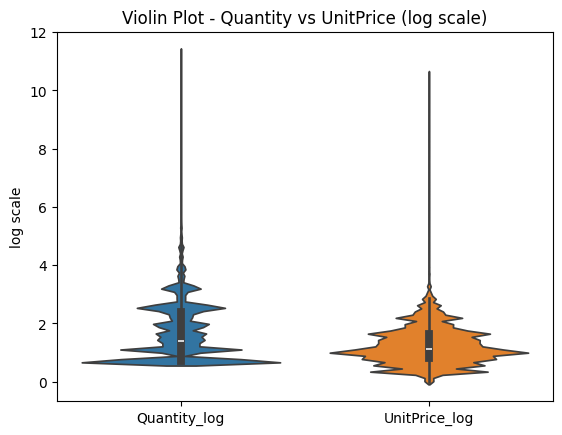

In [118]:
plt.figure()
sns.violinplot(data=df[["Quantity_log", "UnitPrice_log"]])
plt.title("Violin Plot - Quantity vs UnitPrice (log scale)")
plt.ylabel("log scale")
plt.show()

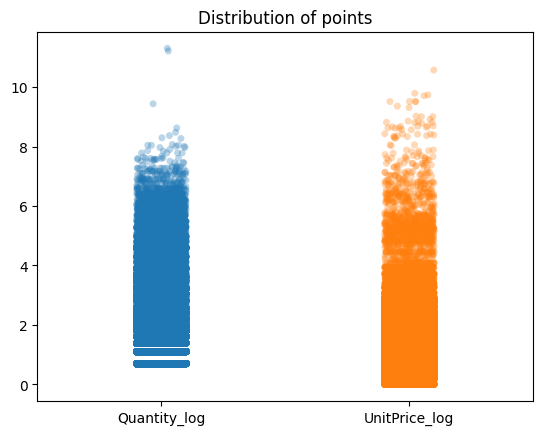

In [119]:
plt.figure()
sns.stripplot(data=df[["Quantity_log", "UnitPrice_log"]], alpha=0.3)
plt.title("Distribution of points")
plt.show()

In [120]:
# Se supone que todas las devoluciones autenticas comienzan por la letra C por 3 razones
# 1 la cantidad es negativa
# 2 el precio es positivo 
# 3 hay customer ID
Devoluciones=df.loc[df["InvoiceNo"].astype(str).str.startswith("C")]
Devoluciones

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,-inf,3.349904
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,-inf,1.731656
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,NaN,0.974560
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,NaN,0.254642
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,NaN,0.254642
...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom,NaN,0.604316
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom,-inf,5.419162
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom,NaN,2.480731
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom,-inf,0.810930


In [121]:
Devoluciones.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID        383
Country             0
Quantity_log     5183
UnitPrice_log       0
dtype: int64

In [122]:
# se supone que si tiene cantidad negativa y no comienza por la letra C es porque 
#son transacciones de la empresa o algo por el estilo
df_neg = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]
df_neg

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom,NaN,0.0
4347,536764,84952C,NaN,-38,12/2/2010 14:42,0.0,NaN,United Kingdom,NaN,0.0
7188,536996,22712,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom,NaN,0.0
7189,536997,22028,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom,NaN,0.0
7190,536998,85067,NaN,-6,12/3/2010 15:30,0.0,NaN,United Kingdom,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,12/7/2011 18:36,0.0,NaN,United Kingdom,NaN,0.0
535335,581212,22578,lost,-1050,12/7/2011 18:38,0.0,NaN,United Kingdom,NaN,0.0
535336,581213,22576,check,-30,12/7/2011 18:38,0.0,NaN,United Kingdom,NaN,0.0
536908,581226,23090,missing,-338,12/8/2011 9:56,0.0,NaN,United Kingdom,NaN,0.0


In [123]:
# Puede que haya transacciones por fuera de los valores anteriores que tengan candidades, se encontro q
#este tipo de transacciones son autenticas de la operacion de la empresa 
df_precio_1 = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] == 0)
]
df_precio_1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom,4.043051,0.0
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom,0.693147,0.0
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.693147,0.0
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.693147,0.0
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom,0.693147,0.0
...,...,...,...,...,...,...,...,...,...,...
535334,581211,22142,check,14,12/7/2011 18:36,0.0,NaN,United Kingdom,2.708050,0.0
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom,3.332205,0.0
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom,5.484797,0.0
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom,5.707110,0.0


In [124]:
# La suma de 1179 + 1336 es igual a todos los valores con precio 0
df_precio_2 = df[
    (df["UnitPrice"] == 0)]
df_precio_2

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom,4.043051,0.0
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom,0.693147,0.0
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.693147,0.0
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.693147,0.0
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom,0.693147,0.0
...,...,...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom,3.332205,0.0
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom,5.484797,0.0
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom,5.707110,0.0
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom,3.044522,0.0


**Se decide BORRAR TODAS las columnas con UNIT PRICE = 0 por los motivos antes mencionados, tener en cuenta que esto es RUIDO generado por las operaciones de la empresa**

In [125]:
Transaccioon_letra1 =df[
    (df["StockCode"].astype(str).str.len() == 1) &
    (df["StockCode"].astype(str).str.isalpha())
]
Transaccioon_letra1["StockCode"].value_counts()

StockCode
M    571
D     77
S     63
B      3
m      1
Name: count, dtype: int64

**Se decide BORRAR todas las filas de StockCode que tengan una sola letra letra ya que son operaciones de la empresa definidas M= Manual, D= discount , S= samples, B= bads, etc**

In [126]:
#cuantos paises hay. 
Paises=df["Country"].value_counts()
Paises

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


Vale la pena hacer un analisis solamente para UK y para el resto del mundo por aparte para realizar segmentos y que el algoritmo no sesge

En este momento, objetivamente tendriamos 4 modelos ya que alrededor del 90% de los datos son de UK y por lo tanto el algoritmo estaria sesgado para interpretar los datos de uk, por lo tanto valdria la pena separar UK del resto del mundo, ahora si se hace esta division seguramente deberia hacerse tambien con respecto al modelo de devoluciones antes planteado.

### 2.1 TRANSFORMACION DE LECTURA

In [129]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%Y %H:%M"
)

### 2.2 DATA CLEANING

LIMPIEZA UNIT PRICE = 0 & STOCK CODE = SOLO UNA LETRA & SOCK CODE REVISION MANUAL DE OPERACION QUE SE HA REALIZADO HASTA EL MOMENTO

### 2.3 Crear Columnas 

In [127]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

Creacion de RFM: Recency(ultimos dias de compra), frequency(cuantas compras hizo) and monetary(cuanto gasto el cliente en total)

In [130]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
...,...,...,...,...
4367,18280.0,278,1,180.60
4368,18281.0,181,1,80.82
4369,18282.0,8,3,176.60
4370,18283.0,4,16,2094.88


### 2.4 Transformacion 

transforma df para los 4 modelos planetados. UK, resto del mundo para transacciones y devoluciones

## 3 PROCESAMIENTO DE DATOS


### 3.2 PIPELINE DE TRANFORMACION NUMERICA

In [131]:
X = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

NameError: name 'KMeans' is not defined

## 4 ESTIMACION DE CLUSTERS A GENERAR

## 5 CONSTRUCCION DEL MODELO (PIPELINES)

# 6 EVALUACION DE LOS RESULTADOS

# 7 ANALISIS DE LOS RESULTADOS